In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weasyprint import HTML
import urllib.request
import astropy.io.fits as fits
from scipy.ndimage import median_filter


# Creating directories
os.makedirs('../plots/continuum', exist_ok=True)
os.makedirs('../plots/zoomed', exist_ok=True)

In [17]:
# Loading in our catalog and taking all of our current "young post starburst" galaxies to be included in this document

classified_df = pd.read_csv('../classified_sample/classified_eBOSS_sample.csv')

# merge target_text from master catalog if it's in a separate file
if os.path.exists('../data/eBOSS_master_catalog.csv'):
    master_df = pd.read_csv('../data/eBOSS_master_catalog.csv')
    if 'TARGET_TEXT' in master_df.columns or 'target_text' in master_df.columns:
        classified_df = classified_df.merge(
            master_df[['PLATE', 'MJD', 'FIBER', [c for c in master_df.columns if 'target' in c.lower()][0]]], 
            on=['PLATE', 'MJD', 'FIBER'], 
            how='left'
        )

# Filtering out only the young psbs (including your S/N >= 2.5 cut)
young_psb_all = classified_df[
    (classified_df['PSB_CLASS'] == 'young PSB') & 
    (classified_df['SN_MEDIAN_ALL'] >= 2.5)
].copy()

# now we assign the full sample and sort by S/N descending (highest S/N first)
galaxy_sample_df = young_psb_all.sort_values(by='SN_MEDIAN_ALL', ascending=False).reset_index(drop=True)

# Make sure everthing actually ran smoothly
print(f"Total young PSBs available in catalog: {len(young_psb_all)}")
print(f"Sample sorted by SN_MEDIAN_ALL (Max S/N: {galaxy_sample_df['SN_MEDIAN_ALL'].max():.2f}, Min S/N: {galaxy_sample_df['SN_MEDIAN_ALL'].min():.2f})")
print(f"Successfully created inspection sample: {len(galaxy_sample_df)} galaxies ready for the PDF block!")

Total young PSBs available in catalog: 307
Sample sorted by SN_MEDIAN_ALL (Max S/N: 38.53, Min S/N: 2.50)
Successfully created inspection sample: 307 galaxies ready for the PDF block!


In [18]:
# Now we must make sure a spectra folder exists inside our data directory
spectra_dir = os.path.join('..', 'data', 'spectra')
os.makedirs(spectra_dir, exist_ok=True)

def download_sdss_spectrum(plate, mjd, fiber, save_path):
    """
    Downloads a single spectrum FITS file from the SDSS server.
    """

    # Weird format parameters to match the SDSS URL
    url = f"https://data.sdss.org/sas/dr17/eboss/spectro/redux/v5_13_2/spectra/lite/{plate:04d}/spec-{plate:04d}-{mjd:05d}-{fiber:04d}.fits"
    try:
        urllib.request.urlretrieve(url, save_path)
        return True
    except Exception as e:
        print(f"Error downloading path {url}: {e}")
        return False


In [19]:
# Now we can actually build our PDF
# MANY of the techniques/code used here I had to find using AI or online resources seeing as I have very little experience with HTML and weasy
# so if anything looks funny or inefficent, please let me know!

html_content = """
<html>
<head>
<style>
    @page { size: letter portrait; margin: 0.4in; }
    body { font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #333; margin: 0; padding: 0; }
    .galaxy-page { page-break-after: always; height: 100%; display: flex; flex-direction: column; }
    .metadata-table { width: 100%; margin-bottom: 15px; border-collapse: collapse; font-size: 12px; }
    .metadata-table th, .metadata-table td { padding: 6px 10px; border: 1px solid #ddd; text-align: left; }
    .metadata-table th { background-color: #f5f5f5; font-weight: bold; }
    .plot-container { text-align: center; margin-bottom: 15px; }
    .plot-img-top { width: 100%; max-height: 4.0in; object-fit: contain; }
    .plot-img-bottom { width: 100%; max-height: 4.0in; object-fit: contain; }
</style>
</head>
<body>
"""

print("Starting dual-panel generation for the sample...")
processed_count = 0

# Make sure BOTH directory targets exist before looping
os.makedirs('../plots/continuum', exist_ok=True)
os.makedirs('../plots/zoomed', exist_ok=True)

# First, we loop through the sample dataframe
for idx, source in galaxy_sample_df.reset_index().drop(columns='index', errors='ignore').iterrows():
    plate = int(source['PLATE'])
    mjd = int(source['MJD'])
    fiber = int(source['FIBER'])
    key = str(source['PMF_STRING'])
    z = float(source['Z'])
    classification = str(source['PSB_CLASS'])
    sn_val = float(source.get('SN_MEDIAN_ALL', 0.0)) # UPDATE 7/23, added context for the new median values

    # Retrieve target_text safely
    target_txt = str(source.get('TARGET_TEXT', source.get('target_text', 'N/A'))).strip()
    
    # Then we locate the local FITS file downloaded in the previous run
    fits_filename = f"spec-{plate:04d}-{mjd:05d}-{fiber:04d}.fits"
    local_fits_path = os.path.join('..', 'data', 'spectra', fits_filename)
    
    # Auto-download from SDSS if the file isn't found locally
    if not os.path.exists(local_fits_path):
        print(f"Downloading missing spectrum for {key} ({fits_filename})...")
        download_sdss_spectrum(plate, mjd, fiber, local_fits_path)

    # double check if download succeeded, I kept running into this issue
    if not os.path.exists(local_fits_path):
        print(f"Warning: Failed to fetch {fits_filename} from SDSS. Skipping.")
        continue
        
    try:
        with fits.open(local_fits_path) as hdul:
            hdu = hdul[1].data
            flux_density_factor = hdu['flux']
            ivar = hdu['ivar']
            log_wav = hdu['loglam']
            
            # vector math 
            flux_density = 10**(-17) * flux_density_factor
            wavelength = 10**log_wav
            
            flux_density_err = np.zeros_like(flux_density)
            good = ivar > 0
            flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
            
            rest_frame_wavelength = wavelength / (1 + z)
            rest_frame_flux_density = flux_density * (1 + z)
            rest_frame_flux_density_err = flux_density_err * (1 + z)
            
            upper = rest_frame_flux_density + rest_frame_flux_density_err
            lower = rest_frame_flux_density - rest_frame_flux_density_err
            
            # Panel one: our continuum, using the same code I used in notebook 02
            med_smooth_rest_flux_c = median_filter(rest_frame_flux_density, size=20, mode='reflect')
            
            fig1 = plt.figure(figsize=(10, 4.5))
            plt.title(f"ID: {key} | Target: {target_txt} | class={classification}, $z$={z:.3f} | S/N={sn_val:.2f}", fontsize=12, pad=15)
            plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=12, labelpad=10)
            plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=12, labelpad=10)
            
            plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.6)
            plt.step(rest_frame_wavelength, med_smooth_rest_flux_c, where='mid', color='red', linewidth=0.6)
            plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.15)
            
            clean_window = (rest_frame_wavelength > 3800) & (rest_frame_wavelength < 7000)
            window_flux = rest_frame_flux_density[clean_window]
            if len(window_flux) > 0:
                continuum_median = np.median(window_flux)
                absolute_floor = np.percentile(window_flux, 1)
                absolute_peak = np.percentile(window_flux, 99.5)
                feature_height = absolute_peak - continuum_median
                ymin = absolute_floor - (abs(absolute_floor) * 0.2 if absolute_floor < 0 else continuum_median * 0.1)
                ymax = continuum_median + (feature_height * 1.2)
                plt.ylim(ymin, ymax)
                
            plt.tight_layout()
            top_plot_path = f"../plots/continuum/{key}_spectrum.png"
            plt.savefig(top_plot_path, bbox_inches='tight', dpi=150)
            plt.close(fig1)

            # Panel two: Our zoomed in spectra, once again, this is just the same as notebook 02
            H_delta, H_alpha, H_beta, OIII = 4102.0, 6563.0, 4861.0, 5007.0
            half_width = 80
            
            med_smooth_rest_flux_l = median_filter(rest_frame_flux_density, size=15, mode='reflect')
            max_observed_rest_wavelength = np.max(rest_frame_wavelength)
            
            if max_observed_rest_wavelength > (H_alpha + half_width):
                right_target = H_alpha
                right_label = r'H$\alpha$'
            elif max_observed_rest_wavelength > (H_beta + half_width):
                right_target = H_beta
                right_label = r'H$\beta$'
            else:
                right_target = OIII
                right_label = r'[OIII]'
                
            fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            fig2.suptitle(f"ID: {key} | Target: {target_txt} | Class: {classification} | $z$ = {z:.3f} | S/N = {sn_val:.2f}", fontsize=13, y=1.02)
            
            # subpanel A: H-delta
            ax1.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', alpha=0.4, linewidth=0.5, label='Data')
            ax1.step(rest_frame_wavelength, med_smooth_rest_flux_l, where='mid', color='red', linewidth=1.0, label='Smoothed')
            ax1.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.1)
            ax1.set_xlim(H_delta - half_width, H_delta + half_width)
            ax1.axvline(H_delta, color='blue', linestyle='--', alpha=0.7, label=r'H$\delta$ (4102 $\AA$)')
            ax1.set_xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=11)
            ax1.set_ylabel(r'$f_{\lambda}$ [$ergs \cdot s^{-1} \cdot cm^{-2} \cdot \AA^{-1}$]', fontsize=11)
            ax1.set_yscale('log', nonpositive='clip')
            ax1.grid(True, which="both", linestyle=':', alpha=0.5)
            ax1.legend(loc='upper right', fontsize=9)
            
            hd_window = (rest_frame_wavelength > (H_delta - half_width)) & (rest_frame_wavelength < (H_delta + half_width))
            hd_flux = rest_frame_flux_density[hd_window]
            if len(hd_flux) > 0:
                # Log scale check! filter out data points equal to or below zero
                pos_hd_flux = hd_flux[hd_flux > 0]
                ymin_hd = np.percentile(pos_hd_flux, 1) if len(pos_hd_flux) > 0 else 1e-18
                ax1.set_ylim(ymin_hd, np.max(hd_flux) * 1.3)
                
            # subpanel B: H-alpha, H-beta or OIII (depending on what is valid)
            ax2.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', alpha=0.4, linewidth=0.5)
            ax2.step(rest_frame_wavelength, med_smooth_rest_flux_l, where='mid', color='red', linewidth=1.0)
            ax2.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.1)
            ax2.set_xlim(right_target - half_width, right_target + half_width)
            ax2.axvline(right_target, color='blue', linestyle='--', alpha=0.7, label=f'{right_label} ({right_target:.0f} $\AA$)')
            ax2.set_xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=11)
            ax2.set_yscale('log', nonpositive='clip')
            ax2.grid(True, which="both", linestyle=':', alpha=0.5)
            ax2.legend(loc='upper right', fontsize=9)
            
            fallback_window = (rest_frame_wavelength > (right_target - half_width)) & (rest_frame_wavelength < (right_target + half_width))
            fallback_flux = rest_frame_flux_density[fallback_window]
            if len(fallback_flux) > 0:
                # Log scale check! filter out data points equal to or below zero
                pos_fb_flux = fallback_flux[fallback_flux > 0]
                ymin_fb = np.percentile(pos_fb_flux, 1) if len(pos_fb_flux) > 0 else 1e-18
                ax2.set_ylim(ymin_fb, np.max(fallback_flux) * 1.3)
                
            plt.tight_layout()
            bottom_plot_path = f"../plots/zoomed/{key}_lines.png"
            plt.savefig(bottom_plot_path, bbox_inches='tight', dpi=150)
            
            plt.close(fig2)
            
            # HTML building
            html_content += f"""
            <div class="galaxy-page">
                <table class="metadata-table">
                    <tr>
                        <th>Target (PMF)</th><td>{key}</td>
                        <th>Target Text</th><td>{target_txt}</td>
                        <th>Redshift (z)</th><td>{z:.4f}</td>
                        <th>Continuum S/N</th><td>{sn_val:.2f}</td>
                        <th>Plate</th><td>{plate}</td>
                        <th>MJD</th><td>{mjd}</td>
                        <th>Fiber</th><td>{fiber}</td>
                    </tr>
                </table>
    
                <div class="plot-container">
                    <img class="plot-img-top" src="../plots/continuum/{key}_spectrum.png">
                </div>
    
                <div class="plot-container">
                    <img class="plot-img-bottom" src="../plots/zoomed/{key}_lines.png">
                </div>
            </div>
            """
            processed_count += 1
            if processed_count % 25 == 0 or processed_count == len(galaxy_sample_df):
                 print(f"Generated assets for {processed_count}/{len(galaxy_sample_df)} galaxies...")
                
    except Exception as e:
        print(f"Failed processing structures for target {key}: {e}")
        plt.close('all')

html_content += "</body></html>"

# final compilation step 
print("\nCompiling master PDF using WeasyPrint...")
HTML(string=html_content, base_url=os.getcwd()).write_pdf('../young_psb_stacked_qc_catalog.pdf')
print("Done!")

Starting dual-panel generation for the sample...
Generated assets for 25/307 galaxies...
Generated assets for 50/307 galaxies...
Generated assets for 75/307 galaxies...
Generated assets for 100/307 galaxies...
Generated assets for 125/307 galaxies...
Generated assets for 150/307 galaxies...
Generated assets for 175/307 galaxies...
Generated assets for 200/307 galaxies...
Generated assets for 225/307 galaxies...
Generated assets for 250/307 galaxies...
Generated assets for 275/307 galaxies...
Generated assets for 300/307 galaxies...
Generated assets for 307/307 galaxies...

Compiling master PDF using WeasyPrint...
Done!


Total sample size: 439
Galaxies with valid H-alpha measurements: 120
Galaxies redshifted out/missing H-alpha: 319

Summary of valid H-alpha EW values:
count    120.000000
mean      13.861720
std       19.257561
min        0.000000
25%        2.095279
50%        6.532465
75%       21.649294
max      165.285930
Name: H_ALPHA_EW, dtype: float64


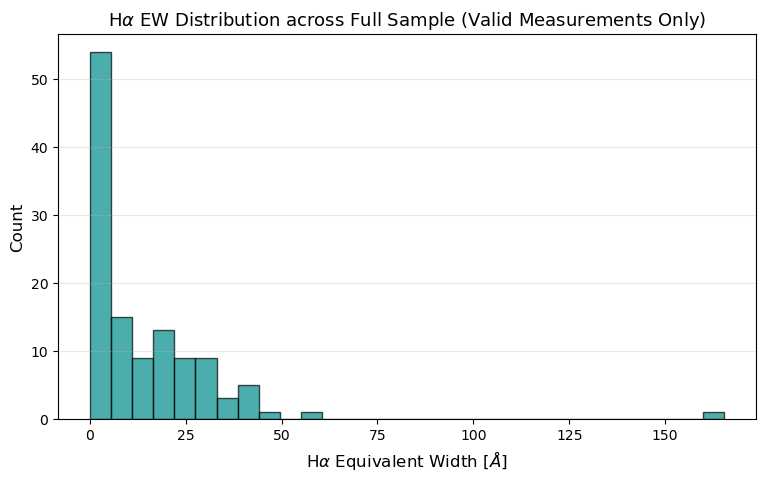

In [25]:
# Post meeting update: building a histogram to see the H-alpha distributions of our current
# young psb galaxy list

# First, filter out the redshifted galaxies just for plotting
valid_ha_sample = young_psb_all[young_psb_all['H_ALPHA_EW'] > -900]

print(f"Total sample size: {len(young_psb_all)}")
print(f"Galaxies with valid H-alpha measurements: {len(valid_ha_sample)}")
print(f"Galaxies redshifted out/missing H-alpha: {len(young_psb_all) - len(valid_ha_sample)}")

# Summary statistics of physical H-alpha values
print("\nSummary of valid H-alpha EW values:")
print(valid_ha_sample['H_ALPHA_EW'].describe())

# plot
plt.figure(figsize=(9, 5))
plt.hist(valid_ha_sample['H_ALPHA_EW'].dropna(), bins=30, color='darkcyan', edgecolor='black', alpha=0.7)
plt.xlabel(r'H$\alpha$ Equivalent Width [$\AA$]', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title(r'H$\alpha$ EW Distribution across Full Sample (Valid Measurements Only)', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [33]:
# Spectral Stacking Blocks: (work in progress)
import sys
import os

# I had to clone SpecStacker in order to download it, so now I must add
# the cloned SpecStacker folder to Python's current search path
sys.path.append(os.path.abspath("./SpecStacker"))

# Now we can import specstacker tools directly
import specstacker as s2
import spectres

print("SpecStacker successfully loaded!")

SpecStacker successfully loaded!


In [35]:
# Now we must configure the paths to our local SpecStacker data files that we have cloned
specstacker_dir = os.path.abspath("./SpecStacker")

line_list = os.path.join(specstacker_dir, "SDSS_emission_lines.txt")
dustmap = os.path.join(specstacker_dir, "dustmaps", "sfddata-master")
filter_curves = os.path.join(specstacker_dir, "SDSS_filter_curves.txt")

In [42]:
# Now we can actually begin using SpecStacker!
candidate_ids = [
    "03656-55241-0030", "04048-55602-0822", "03864-55649-0648", "06676-56389-0447",
    "03979-55597-0491", "07752-58072-0792", "07718-57362-0412", "06402-56334-0949"
]

wave_list = []
flux_list = []
sigma_list = []
z_list = []
ra_list = []
dec_list = []

for spec_id in candidate_ids:
    # step one: lookup catalog metadata from our own catalog
    row = classified_df[classified_df['PMF_STRING'] == spec_id].iloc[0]
    
    z_val = row['Z']
    ra_val = row['RA']
    dec_val = row['DEC']
    
    plate_str = f"{int(row['PLATE']):04d}"
    mjd_str = str(int(row['MJD']))
    fiber_str = f"{int(row['FIBER']):04d}"

    # step two: construct a new FITS name
    fits_filename = f"spec-{plate_str}-{mjd_str}-{fiber_str}.fits"
    local_fits_path = os.path.join(spectra_dir, fits_filename)

    # step three: now we can read the spectral data from the FITS file
    with fits.open(local_fits_path) as hdul:
        data = hdul[1].data
        
        # read the wavelength array which is log-linear converted to A
        if 'loglam' in data.names:
            w_arr = 10**data['loglam']
        elif 'wavelength' in data.names:
            w_arr = data['wavelength']
        else:
            w_arr = 10**data['log_wav']
            
        f_arr = data['flux']

        # now convert inverse variance to standard deviation
        ivar_arr = data['ivar']
        sigma_arr = np.full_like(ivar_arr, 1e6, dtype=float)  # we default high noise for masked pixels
        positive_mask = ivar_arr > 0
        sigma_arr[positive_mask] = 1.0 / np.sqrt(ivar_arr[positive_mask])

    # step four: append the lists for specstacker
    wave_list.append(w_arr)
    flux_list.append(f_arr)
    sigma_list.append(sigma_arr)
    z_list.append(z_val)
    ra_list.append(ra_val)
    dec_list.append(dec_val)

# step five: make sure everything actually ran
print(f"Successfully loaded {len(wave_list)} candidates!")
print(f"  Wavelength range: {wave_list[0].min():.2f} A to {wave_list[0].max():.2f} A")

Successfully loaded 8 candidates!
  Wavelength range: 3562.87 A to 10322.86 A


In [47]:
# now we can actually do the stacking 
stacks, stacks_sim, stacks_corr, spec_idx = s2.stack_spectra(
    wave_arr,
    flux_arr,
    sigma_arr,
    z=z_arr,
    RA=ra_arr,
    DEC=dec_arr
)

print("Stacking complete!")

# Andddd now we extract arrays from the corrected stack dictionary 
bin_key = list(stacks_corr.keys())[0]

stacked_wave = stacks_corr[bin_key]['wln']
stacked_flux = stacks_corr[bin_key]['flux']
stacked_err  = stacks_corr[bin_key]['flux_err']
stacked_N    = stacks_corr[bin_key]['N']

print(f"Redshift key: {bin_key}")
print(f"Rest-frame stacked wavelength array shape: {stacked_wave.shape}")
print(f"Stacked flux array shape: {stacked_flux.shape}")

zbin: [(np.float64(0.5749510526657104), np.float64(0.9940577149391174))]
Number of spectra to stack =  8
Spectra corrected for foreground extinction.


/Users/hgrossmeyer/Documents/young-post-starburst-classification/notebooks/SpecStacker/specstacker.py:165: UserWarning: Input line 33 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  em_list = np.loadtxt(line_list_dir, dtype='str', delimiter=',')


Number of divisions used for the correction: 17
Stacking complete!
Redshift key: zbin=0
Rest-frame stacked wavelength array shape: (4809,)
Stacked flux array shape: (4809,)


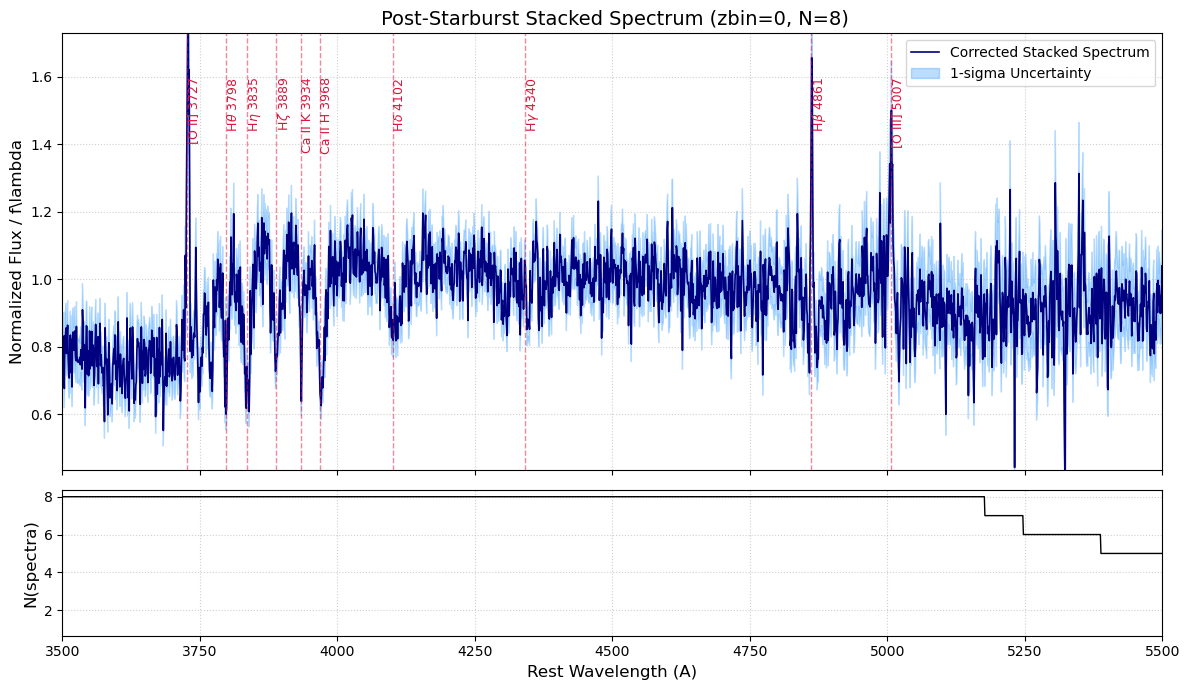

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Okay, we need to filter out extreme spikes for reasonable y-limits
# (This can be adjusted)
valid_mask = (stacked_wave >= 3500) & (stacked_wave <= 5500)
valid_flux = stacked_flux[valid_mask]

# Here we find sensible percentile-based y limits (ignores giant negative/positive spikes, this was a problem at first)
ymin = np.nanpercentile(valid_flux, 1) - 0.2
ymax = np.nanpercentile(valid_flux, 99) + 0.5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# top panel: the actual stacked spectrum
ax1.plot(stacked_wave, stacked_flux, color='navy', lw=1.2, label='Corrected Stacked Spectrum')
ax1.fill_between(stacked_wave, stacked_flux - stacked_err, stacked_flux + stacked_err, 
                 color='dodgerblue', alpha=0.3, label=r'1-sigma Uncertainty')

# we need to explicitly set x and y limits to focus on the galaxy optical rest-frame
ax1.set_xlim(3500, 5500)
ax1.set_ylim(ymin, ymax)

ax1.set_ylabel(r'Normalized Flux / f\lambda', fontsize=12)
ax1.set_title(f' Post-Starburst Stacked Spectrum ({bin_key}, N=8)', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Line markers for the important stuff
key_lines = {
    r'[O II] 3727': 3727.0,
    r'H$\theta$ 3798': 3797.9,
    r'H$\eta$ 3835': 3835.4,
    r'H$\zeta$ 3889': 3889.1,
    r'Ca II K 3934': 3933.7,
    r'Ca II H 3968': 3968.5,
    r'H$\delta$ 4102': 4101.7,
    r'H$\gamma$ 4340': 4340.5,
    r'H$\beta$ 4861': 4861.3,
    r'[O III] 5007': 5006.8
}

for line_name, rest_wln in key_lines.items():
    if 3500 <= rest_wln <= 5500:
        ax1.axvline(rest_wln, color='crimson', linestyle='--', alpha=0.5, lw=1)
        ax1.text(rest_wln, ymax - 0.1*(ymax-ymin), f' {line_name}', 
                 rotation=90, verticalalignment='top', fontsize=9, color='crimson')

# bottom panel: Coverage across the current candidates that we are using (and I could've used poor examples)
ax2.plot(stacked_wave, stacked_N, color='black', lw=1)
ax2.set_xlabel(r'Rest Wavelength (A)', fontsize=12)
ax2.set_ylabel(r'N(spectra)', fontsize=12)
ax2.set_xlim(3500, 5500)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# .4-.6 redshift range for first umap on full catalog
# larger catalog with S/N cuts first then our smaller catalog